In [ ]:
import pandas as pd 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [6]:
df=pd.read_csv(r"C:\Users\moham\OneDrive\سطح المكتب\used_car_sales.csv")
pd.set_option('display.max_columns', None)
df

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,Energy,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
0,O2KE18,Carmudi,California,Fortuner,Toyota,SUV,Gray,Automatic,8,5,Hybrid,2021,8800,67948,200,2022-10-26,Un Sold,1970-01-01,8296,0,0,Pranav,1,0,Average
1,EPMPC8,Carousell,Philadelphia,Creta,Hyundai,Hatchback,Blue,Automatic,5,5,Hybrid,2018,7600,34637,113,2017-08-25,Sold,2021-03-03,5659,4770,-16,Vihaan,5,0,Good
2,SQKXAP,Carsome,North Carolina,Scorpio,Mahindra,SUV,Gray,Automatic,5,5,Hybrid,2016,9300,33274,120,2018-06-13,Un Sold,1970-01-01,8430,0,0,Aarush,4,0,Good
3,PWP2QK,Trivett,North Carolina,Plato,Prazo,Convertible,Gray,Automatic,2,2,Petrol,2021,8800,46250,250,2023-05-14,Sold,2024-04-02,6919,7942,15,Anushka,1,205,Average
4,FNDDKM,Zupps,Portland,Dzire,Maruti,Sedan,Red,Automatic,5,5,Electric,2019,8500,29323,100,2022-08-24,Un Sold,1970-01-01,6864,0,0,Pavan,3,0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ZHLCSG,APE,Texas,Yodha,Tata,Truck,Blue,Manual,3,2,Diesel,2024,7100,55333,100,2023-12-29,Sold,2024-03-23,6102,5041,-17,Supriya,3,0,Excellent
9996,2BJE0Y,Carsome,Portland,Scorpio,Mahindra,SUV,Black,Automatic,5,5,Hybrid,2018,9100,74986,120,2019-06-13,Un Sold,1970-01-01,8108,0,0,Aarush,4,0,Excellent
9997,4OVJ83,Trust,North Carolina,Seltos,Kia,Hatchback,Black,Automatic,5,5,Hybrid,2020,7400,53815,150,2020-02-17,Un Sold,1970-01-01,5945,0,0,Pranav,4,0,Poor
9998,M2ECXT,Carsome,Detroit,Swift,Maruti,Sedan,Black,Automatic,5,4,Diesel,2016,7400,52105,115,2018-05-03,Un Sold,1970-01-01,6893,0,0,Swathi,2,0,Average


In [3]:
df_back = df.copy()  

In [52]:
df.sample(n=100)

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,Energy,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
1035,TI9ZKF,Ahg,Texas,Hilux,Toyota,Truck,Gray,Manual,4,2,Hybrid,2015,8900,48917,200,2017-10-08,Un Sold,1970-01-01,8357,0,0,Piyush,1,0,Excellent
1792,YDISX4,Knox,San Jose,Seltos,Kia,Hatchback,Red,Automatic,5,5,Electric,2017,8200,83436,150,2018-12-01,Un Sold,1970-01-01,6807,0,0,Supriya,5,0,Excellent
8328,0XIO7Z,Cars24,Oklahoma,Etriga,Maruti,Hatchback,Red,Automatic,4,5,Diesel,2020,6500,74849,103,2022-05-22,Sold,2024-05-18,4817,5603,16,Bhavani,2,157,Poor
5479,35PKHI,Carsome,Utah,Thar,Mahindra,SUV,Blue,Manual,5,3,Hybrid,2023,8600,69953,130,2015-03-12,Un Sold,1970-01-01,7699,0,0,Aarush,3,0,Good
516,468U76,Automart,Columbus,Dzire,Maruti,Sedan,Blue,Automatic,5,5,Electric,2020,8400,64781,100,2018-02-26,Un Sold,1970-01-01,6951,0,0,Shailaja,2,0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,3NIUA4,Trivett,Denver,Etriga,Maruti,Hatchback,Red,Manual,4,5,Hybrid,2022,7200,60078,103,2021-06-03,Sold,2021-10-16,5678,6334,12,Pranav,1,131,Good
9987,WOEFOX,Marchi,New York,Swift,Maruti,Sedan,Black,Manual,5,4,Petrol,2020,6900,41604,115,2016-02-04,Un Sold,1970-01-01,5670,0,0,Shiva,2,0,Good
7172,78KO32,Automart,New York,Seltos,Kia,Hatchback,Blue,Manual,5,5,Electric,2023,7600,72782,150,2016-10-21,Un Sold,1970-01-01,6739,0,0,Vihaan,1,0,Excellent
6504,GGU05T,Olx,North Carolina,Hilux,Toyota,Truck,Blue,Automatic,4,2,Petrol,2024,7000,58637,200,2020-10-25,Un Sold,1970-01-01,5651,0,0,Shiva,5,0,Average


In [5]:
df.isnull().sum()

ID                    0
Distributor Name      0
Location              0
Car Name              0
Manufacturer Name     0
Car Type              0
Color                 0
Gearbox               0
Number of Seats       0
Number of Doors       0
Energy                0
Manufactured Year     0
Price-$               0
Mileage-KM            0
Engine Power-HP       0
Purchased Date        0
Car Sale Status       0
Sold Date             0
Purchased Price-$     0
Sold Price-$          0
Margin-%              0
Sales Agent Name      0
Sales Rating          0
Sales Commission-$    0
Feedback              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  10000 non-null  object
 1   Distributor Name    10000 non-null  object
 2   Location            10000 non-null  object
 3   Car Name            10000 non-null  object
 4   Manufacturer Name   10000 non-null  object
 5   Car Type            10000 non-null  object
 6   Color               10000 non-null  object
 7   Gearbox             10000 non-null  object
 8   Number of Seats     10000 non-null  int64 
 9   Number of Doors     10000 non-null  int64 
 10  Energy              10000 non-null  object
 11  Manufactured Year   10000 non-null  int64 
 12  Price-$             10000 non-null  int64 
 13  Mileage-KM          10000 non-null  int64 
 14  Engine Power-HP     10000 non-null  int64 
 15  Purchased Date      10000 non-null  object
 16  Car Sale Status     100

In [ ]:
# Data Cleaning

In [8]:
df['Sold Date']=pd.to_datetime(df['Sold Date'])
df['Purchased Date']=pd.to_datetime(df['Purchased Date'])

In [9]:
df.head().T

,0,1,2,3,4
ID,O2KE18,EPMPC8,SQKXAP,PWP2QK,FNDDKM
Distributor Name,Carmudi,Carousell,Carsome,Trivett,Zupps
Location,California,Philadelphia,North Carolina,North Carolina,Portland
Car Name,Fortuner,Creta,Scorpio,Plato,Dzire
Manufacturer Name,Toyota,Hyundai,Mahindra,Prazo,Maruti
Car Type,SUV,Hatchback,SUV,Convertible,Sedan
Color,Gray,Blue,Gray,Gray,Red
Gearbox,Automatic,Automatic,Automatic,Automatic,Automatic
Number of Seats,8,5,5,2,5
Number of Doors,5,5,5,2,5


In [10]:
df.describe()

,Number of Seats,Number of Doors,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Rating,Sales Commission-$
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.786000,4.081000,2019.525200,7975.100000,45497.531800,143.344700,2020-01-09 21:10:30.719999744,1981-04-28 23:35:57.119999936,6720.617700,1487.776100,0.428200,3.004500,17.809100
min,2.000000,2.000000,2015.000000,6000.000000,1000.000000,100.000000,2015-01-01 00:00:00,1970-01-01 00:00:00,4015.000000,0.000000,-26.000000,1.000000,0.000000
25%,4.000000,3.000000,2017.000000,7200.000000,22530.250000,113.000000,2017-07-07 18:00:00,1970-01-01 00:00:00,5937.000000,0.000000,0.000000,2.000000,0.000000
50%,5.000000,5.000000,2020.000000,7900.000000,44471.500000,120.000000,2020-01-13 00:00:00,1970-01-01 00:00:00,6685.000000,0.000000,0.000000,3.000000,0.000000
75%,5.000000,5.000000,2022.000000,8700.000000,66292.500000,175.000000,2022-07-15 00:00:00,1970-01-01 00:00:00,7481.250000,0.000000,0.000000,4.000000,0.000000
max,8.000000,5.000000,2024.000000,10900.000000,99983.000000,250.000000,2024-12-31 00:00:00,2025-02-16 00:00:00,10383.000000,11657.000000,33.000000,5.000000,308.000000
std,1.466499,1.266807,2.886693,1018.829618,26867.899798,44.762333,NaN,NaN,1110.840531,2900.679397,5.811697,1.408644,57.135284


In [11]:
df.describe(include="O")

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Energy,Car Sale Status,Sales Agent Name,Feedback
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,21,17,13,8,5,5,2,4,2,27,4
top,G0K5HM,Cars24,North Carolina,Yodha,Maruti,SUV,Blue,Automatic,Hybrid,Un Sold,Krishna,Excellent
freq,1,520,1075,830,2263,3167,2353,5093,2536,7834,410,4117


In [12]:
Un_Sold=df[df["Car Sale Status"]=="Un Sold"] 
Un_Sold

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,Energy,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
0,O2KE18,Carmudi,California,Fortuner,Toyota,SUV,Gray,Automatic,8,5,Hybrid,2021,8800,67948,200,2022-10-26,Un Sold,1970-01-01,8296,0,0,Pranav,1,0,Average
2,SQKXAP,Carsome,North Carolina,Scorpio,Mahindra,SUV,Gray,Automatic,5,5,Hybrid,2016,9300,33274,120,2018-06-13,Un Sold,1970-01-01,8430,0,0,Aarush,4,0,Good
4,FNDDKM,Zupps,Portland,Dzire,Maruti,Sedan,Red,Automatic,5,5,Electric,2019,8500,29323,100,2022-08-24,Un Sold,1970-01-01,6864,0,0,Pavan,3,0,Poor
6,KPRE75,Cars24,New York,Thar,Mahindra,SUV,Gray,Automatic,5,3,Hybrid,2015,9400,83208,130,2021-09-28,Un Sold,1970-01-01,8470,0,0,Pavan,1,0,Excellent
7,8C1O0B,Ahg,Denver,Etriga,Maruti,Hatchback,Black,Automatic,4,5,Hybrid,2023,7100,21926,103,2020-09-26,Un Sold,1970-01-01,5143,0,0,Shiva,4,0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,MKZNXL,Nufor,Chicago,Thar,Mahindra,SUV,Red,Manual,5,3,Electric,2023,9100,12828,130,2021-06-08,Un Sold,1970-01-01,7403,0,0,Krishna,1,0,Average
9996,2BJE0Y,Carsome,Portland,Scorpio,Mahindra,SUV,Black,Automatic,5,5,Hybrid,2018,9100,74986,120,2019-06-13,Un Sold,1970-01-01,8108,0,0,Aarush,4,0,Excellent
9997,4OVJ83,Trust,North Carolina,Seltos,Kia,Hatchback,Black,Automatic,5,5,Hybrid,2020,7400,53815,150,2020-02-17,Un Sold,1970-01-01,5945,0,0,Pranav,4,0,Poor
9998,M2ECXT,Carsome,Detroit,Swift,Maruti,Sedan,Black,Automatic,5,4,Diesel,2016,7400,52105,115,2018-05-03,Un Sold,1970-01-01,6893,0,0,Swathi,2,0,Average


In [13]:
Sold=df[df["Car Sale Status"]=="Sold"] 
Sold

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,Energy,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
1,EPMPC8,Carousell,Philadelphia,Creta,Hyundai,Hatchback,Blue,Automatic,5,5,Hybrid,2018,7600,34637,113,2017-08-25,Sold,2021-03-03,5659,4770,-16,Vihaan,5,0,Good
3,PWP2QK,Trivett,North Carolina,Plato,Prazo,Convertible,Gray,Automatic,2,2,Petrol,2021,8800,46250,250,2023-05-14,Sold,2024-04-02,6919,7942,15,Anushka,1,205,Average
5,I5D584,Zupps,Denver,Fortuner,Toyota,SUV,Red,Automatic,8,5,Electric,2021,9300,38716,200,2022-06-05,Sold,2024-11-02,8533,9929,16,Preeti,5,279,Excellent
14,IKYB6R,Nufor,Tucson,Scorpio,Mahindra,SUV,Red,Automatic,5,5,Electric,2021,9300,95835,120,2022-12-31,Sold,2022-10-22,8557,8896,4,Swathi,2,68,Excellent
17,U7L0OA,Carmix,Philadelphia,Creta,Hyundai,Hatchback,Red,Automatic,5,5,Diesel,2016,6900,66534,113,2022-07-15,Sold,2024-05-10,6382,5418,-15,Vishwajeet,1,0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9961,1LMJ4Z,Cars24,Oklahoma,Swift,Maruti,Sedan,Red,Manual,5,4,Petrol,2016,7300,37448,115,2019-01-06,Sold,2024-05-22,6544,6255,-4,Vihaan,3,0,Excellent
9981,CFT40G,Skipper,Philadelphia,Etriga,Maruti,Hatchback,Black,Automatic,4,5,Petrol,2016,6800,60579,103,2020-08-22,Sold,2021-04-17,5962,6110,2,Swathi,1,30,Excellent
9983,G0K5HM,Motor,Tennessee,Seltos,Kia,Hatchback,Red,Automatic,5,5,Hybrid,2018,7600,68001,150,2022-10-27,Sold,2023-05-10,6751,7361,9,Rithvik,5,122,Excellent
9993,FCFG98,Carmudi,Florida,Scorpio,Mahindra,SUV,Black,Automatic,5,5,Petrol,2021,7800,96006,120,2015-03-22,Sold,2016-02-11,7033,6857,-3,Krishna,3,0,Good


In [14]:
Sold['The_days'] = (df['Sold Date'] - df['Purchased Date']).dt.days 


C:\Users\dell\AppData\Local\Temp\ipykernel_7664\3977498206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Sold['The_days'] = (df['Sold Date'] - df['Purchased Date']).dt.days


In [15]:
Sold.head().T

,1,3,5,14,17
ID,EPMPC8,PWP2QK,I5D584,IKYB6R,U7L0OA
Distributor Name,Carousell,Trivett,Zupps,Nufor,Carmix
Location,Philadelphia,North Carolina,Denver,Tucson,Philadelphia
Car Name,Creta,Plato,Fortuner,Scorpio,Creta
Manufacturer Name,Hyundai,Prazo,Toyota,Mahindra,Hyundai
Car Type,Hatchback,Convertible,SUV,SUV,Hatchback
Color,Blue,Gray,Red,Red,Red
Gearbox,Automatic,Automatic,Automatic,Automatic,Automatic
Number of Seats,5,2,8,5,5
Number of Doors,5,2,5,5,5


In [16]:
Sold.sample(n=10).T

,9504,8416,6615,8152,8324,4955,3270,3208,9874,5046
ID,80ATAD,59ZYP0,12K902,6KNCKR,MJ8H7R,40PVB9,VDYFJL,0JEUGD,2ISCY4,CEJS3W
Distributor Name,Sobri,Automart,Skipper,Motor,Knox,Knox,Oto,Knox,Olx,Motor
Location,Tennessee,Portland,Columbus,New York,Madison,Tennessee,Texas,Portland,Oklahoma,Denver
Car Name,Hilux,Plato,Dzire,Dzire,Creta,Kags,Plato,Dzire,Kags,Seltos
Manufacturer Name,Toyota,Prazo,Maruti,Maruti,Hyundai,Renault,Prazo,Maruti,Renault,Kia
Car Type,Truck,Convertible,Sedan,Sedan,Hatchback,SUV,Convertible,Sedan,SUV,Hatchback
Color,Black,White,Gray,Black,Blue,Blue,White,Black,Blue,Blue
Gearbox,Manual,Manual,Automatic,Automatic,Automatic,Manual,Manual,Manual,Manual,Automatic
Number of Seats,4,2,5,5,5,7,2,5,7,5
Number of Doors,2,2,5,5,5,5,2,5,5,5


In [17]:
Sold.describe()

,Number of Seats,Number of Doors,Manufactured Year,Price-$,Mileage-KM,Engine Power-HP,Purchased Date,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Rating,Sales Commission-$,The_days
count,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166,2166,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000
mean,4.775623,4.058172,2019.628347,7972.853186,45146.978763,144.446907,2020-01-04 17:49:01.828254976,2022-04-13 00:41:53.019390464,6740.786704,6868.772392,1.976916,2.978763,82.221145,829.286704
min,2.000000,2.000000,2015.000000,6000.000000,1011.000000,100.000000,2015-01-03 00:00:00,2015-03-06 00:00:00,4125.000000,3091.000000,-26.000000,1.000000,0.000000,-280.000000
25%,4.000000,3.000000,2017.000000,7200.000000,21633.750000,113.000000,2017-06-21 12:00:00,2020-10-08 12:00:00,5954.750000,5893.000000,-8.750000,2.000000,0.000000,127.500000
50%,5.000000,5.000000,2020.000000,7900.000000,44781.500000,120.000000,2019-12-27 00:00:00,2022-12-16 12:00:00,6678.500000,6839.500000,2.000000,3.000000,29.000000,553.000000
75%,5.000000,5.000000,2022.000000,8675.000000,65685.750000,175.000000,2022-07-15 18:00:00,2024-03-20 00:00:00,7494.500000,7802.250000,12.000000,4.000000,161.000000,1330.500000
max,8.000000,5.000000,2024.000000,10900.000000,99943.000000,250.000000,2024-12-30 00:00:00,2025-02-16 00:00:00,10332.000000,11657.000000,33.000000,5.000000,308.000000,3608.000000
std,1.515273,1.285677,2.901128,1018.585662,27115.099853,45.885103,NaN,NaN,1123.729436,1371.740344,12.366476,1.398287,98.885095,844.563699


In [18]:
Sold.describe(include="O")

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Energy,Car Sale Status,Sales Agent Name,Feedback
count,2166,2166,2166,2166,2166,2166,2166,2166,2166,2166,2166,2166
unique,2166,21,17,13,8,5,5,2,4,1,27,4
top,ZHLCSG,Marchi,North Carolina,Yodha,Maruti,Hatchback,Blue,Automatic,Electric,Sold,Pavan,Excellent
freq,1,118,237,194,473,679,532,1090,557,2166,97,896


In [19]:
df["Sales Agent Name"].value_counts()

Sales Agent Name
Krishna       410
Aditya        401
Bhavani       389
Hariom        388
Shailaja      386
Preeti        385
Pavan         385
Supriya       383
Vishwajeet    383
Aarush        379
Dhruv         379
Shilpa        377
Swathi        376
Karan         375
Narayan       374
Anushka       370
Rithvik       363
Swapna        360
Piyush        358
Ram           357
Pranav        355
Shiva         351
Sweta         351
Vihaan        348
Shruthi       346
Arjuna        341
Sai           330
Name: count, dtype: int64

In [20]:
df["Manufacturer Name"].value_counts()

Manufacturer Name
Maruti      2263
Mahindra    1598
Toyota      1549
Hyundai     1516
Tata         830
Renault      791
Kia          773
Prazo        680
Name: count, dtype: int64

In [21]:
df["Energy"].value_counts()

Energy
Hybrid      2536
Diesel      2507
Petrol      2483
Electric    2474
Name: count, dtype: int64

In [22]:
df["Car Sale Status"].value_counts()

Car Sale Status
Un Sold    7834
Sold       2166
Name: count, dtype: int64

In [23]:
df["Feedback"].value_counts()

Feedback
Excellent    4117
Good         2944
Average      2011
Poor          928
Name: count, dtype: int64

In [24]:
df["Car Type"].value_counts()

Car Type
SUV            3167
Hatchback      3098
Truck          1601
Sedan          1454
Convertible     680
Name: count, dtype: int64

In [25]:
df["Distributor Name"].value_counts()

Distributor Name
Cars24       520
Carmix       505
Zupps        500
Oto          489
Olx          488
Skipper      486
Sobri        485
Marchi       484
Carousell    480
APE          480
Knox         480
Carmudi      472
Kamkar       471
Automart     468
Trust        463
Motor        459
Nufor        459
Carsome      457
Trivett      452
Ahg          452
Carro        450
Name: count, dtype: int64

In [26]:
df["Location"].value_counts()

Location
North Carolina    1075
Tennessee          632
Detroit            605
Chicago            590
Denver             583
Columbus           575
Tucson             568
Texas              564
New York           564
Utah               549
California         546
San Jose           544
Philadelphia       540
Florida            531
Oklahoma           529
Portland           518
Madison            487
Name: count, dtype: int64

In [27]:
df["Gearbox"].value_counts()

Gearbox
Automatic    5093
Manual       4907
Name: count, dtype: int64

In [28]:
df.head().T

,0,1,2,3,4
ID,O2KE18,EPMPC8,SQKXAP,PWP2QK,FNDDKM
Distributor Name,Carmudi,Carousell,Carsome,Trivett,Zupps
Location,California,Philadelphia,North Carolina,North Carolina,Portland
Car Name,Fortuner,Creta,Scorpio,Plato,Dzire
Manufacturer Name,Toyota,Hyundai,Mahindra,Prazo,Maruti
Car Type,SUV,Hatchback,SUV,Convertible,Sedan
Color,Gray,Blue,Gray,Gray,Red
Gearbox,Automatic,Automatic,Automatic,Automatic,Automatic
Number of Seats,8,5,5,2,5
Number of Doors,5,5,5,2,5


# Machine Learning — Car Price Prediction

## Final ML Objective

After exploring the dataset, we initially considered **Car Sale Status** as a classification target.  
We tested Logistic Regression, Decision Tree, and Random Forest, but the classification results were weak.

We therefore changed the target to **`Price-$`**, which represents the initial price of the car when it was listed for sale. This turns the problem into a **Regression** task.

### Final objective
> Predict the initial car listing price (`Price-$`) using the available characteristics of the car.


## What happened during the ML process?

### 1. Initial Classification attempt
We first tried to predict **Car Sale Status (Sold / Un Sold)**.

The class distribution was imbalanced:
- Un Sold: 78.35%
- Sold: 21.65%

The tested classification models produced low F1 scores, so this target did not provide strong predictive performance with the available features.

### 2. Target reassessment
We investigated another possible target: **`Price-$`**.

The correlation analysis showed much stronger relationships with several vehicle attributes, especially:
- `Purchased Price-$`: 0.9205
- `Engine Power-HP`: 0.4939
- `Number of Doors`: -0.3579
- `Manufactured Year`: -0.2906

Because `Price-$` is the initial listing price, it is also a meaningful business target.

### 3. Avoiding data leakage
For the final regression model, we removed information that should not be used when predicting the initial listing price, including post-sale information such as:
- `Car Sale Status`
- `Sold Date`
- `Sold Price-$`
- `Margin-%`
- `Sales Commission-$`
- `Sales Rating`
- `Feedback`

We also excluded `Purchased Price-$` so that the model would not depend directly on the purchase price.

### 4. Final regression models
We compared:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The models were evaluated using **MAE, RMSE, and R²**.


In [ ]:
df_reg = df.copy()

df_reg["Purchased Date"] = pd.to_datetime(
    df_reg["Purchased Date"],
    errors="coerce"
)

df_reg["Purchased Year"] = df_reg["Purchased Date"].dt.year

df_reg["Car Age"] = (
    df_reg["Purchased Year"] - df_reg["Manufactured Year"]
)

df_reg.drop(columns=["Purchased Date"], inplace=True)


In [ ]:
target = "Price-$"

excluded_columns = [
    "ID",
    "Purchased Price-$",  
    "Car Name",            
    "Distributor Name",   
    "Sales Agent Name",
    "Car Sale Status",
    "Sold Date",
    "Sold Price-$",
    "Margin-%",
    "Sales Commission-$",
    "Sales Rating",
    "Feedback"
]

X = df_reg.drop(columns=[target] + excluded_columns)
y = df_reg[target]



X shape: (10000, 15)
y shape: (10000,)


In [ ]:
numeric_X = X.select_dtypes(include=np.number)

price_corr = (
    numeric_X
    .corrwith(y)
    .sort_values(ascending=False)
)

price_corr


Engine Power-HP        0.493879
Car Age                0.201977
Number of Seats        0.010557
Purchased DayOfWeek    0.007026
Mileage-KM             0.002280
Purchased Year        -0.004956
Purchased Month       -0.023180
Manufactured Year     -0.290610
Number of Doors       -0.357902
dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)



Training set: (8000, 15)
Testing set: (2000, 15)


In [ ]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Number of Seats', 'Number of Doors', 'Manufactured Year', 'Mileage-KM', 'Engine Power-HP', 'Purchased Year', 'Purchased Month', 'Purchased DayOfWeek', 'Car Age']
Categorical features: ['Location', 'Manufacturer Name', 'Car Type', 'Color', 'Gearbox', 'Energy']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


## Regression Models

- **Linear Regression** 
- **Decision Tree Regressor** 
- **Random Forest Regressor** 


In [ ]:
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=10,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ])
}


In [ ]:
# Train models 

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["R²", "MAE"],
    ascending=[False, True]
).reset_index(drop=True)

results_df.round(3)


,Model,MAE,RMSE,R²
0,Linear Regression,0.000,0.000,1.0
1,Random Forest,0.040,0.288,1.0
2,Decision Tree,3.672,13.652,1.0


### Observed final results

**Linear Regression was selected as the best model because it achieved the lowest MAE and RMSE while also achieving an R² of 1.0.**

> Note: The exceptionally high performance is a characteristic of this dataset. The target contains only 50 unique price values across 10,000 records,  Duplicate rows and duplicate feature combinations were also checked during investigation and were not found.


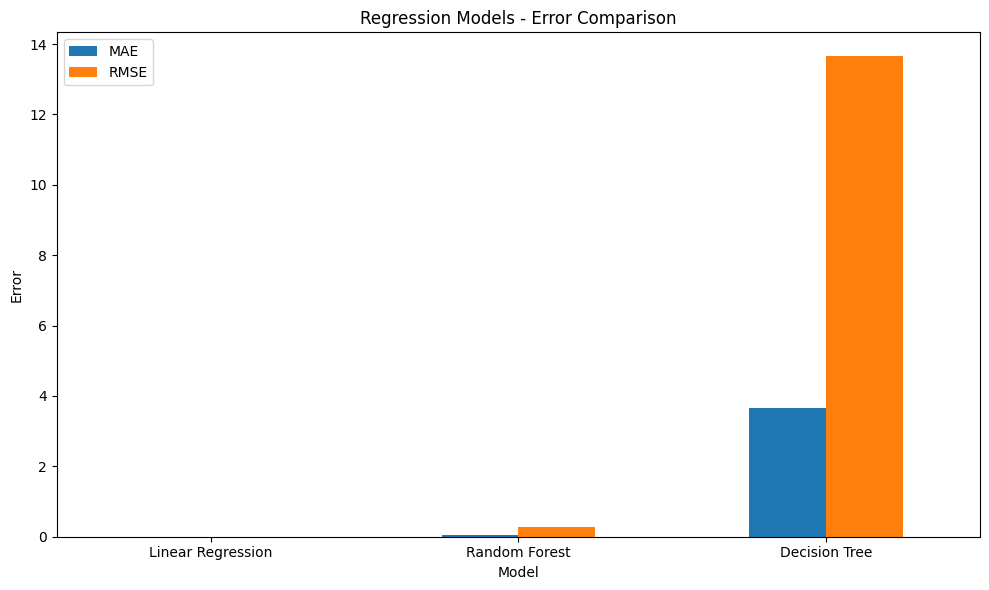

In [ ]:
results_plot = results_df.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Models - Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


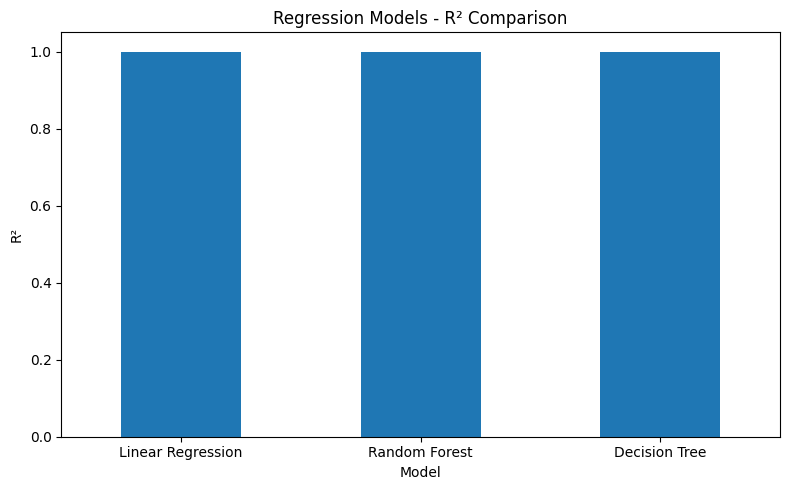

In [ ]:
results_plot["R²"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Regression Models - R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


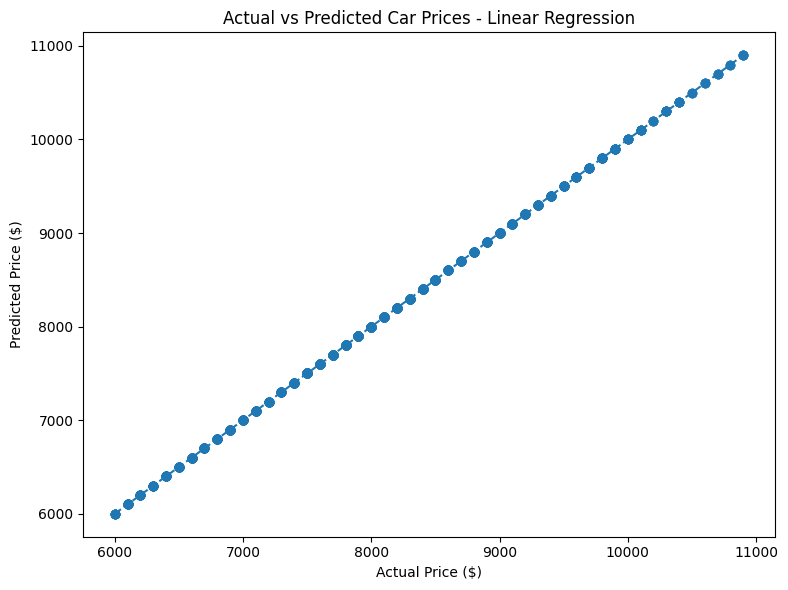

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted Car Prices - {best_model_name}")

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()


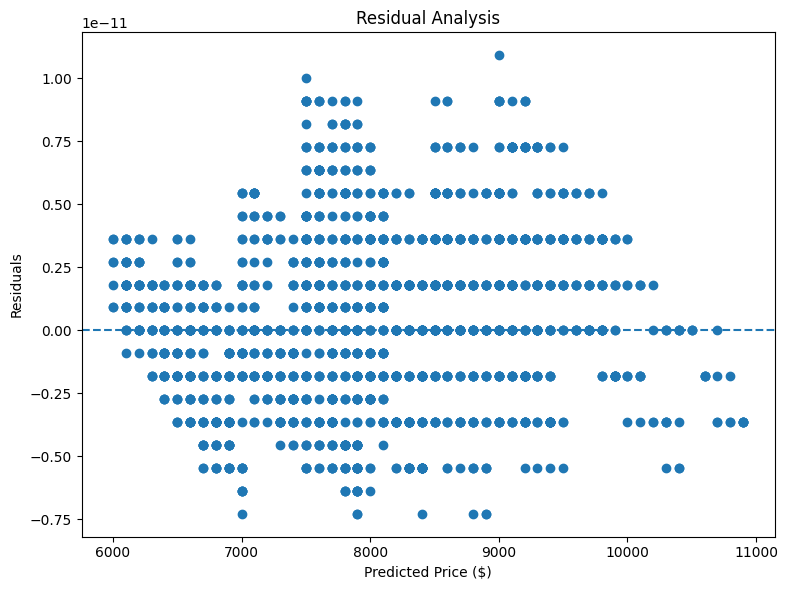

In [ ]:
# Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()


## Final ML Conclusion

The original classification task attempted to predict whether a car was **Sold or Un Sold**, but the tested classification models produced weak predictive performance.

After reassessing the target variable, **`Price-$`** was selected because it represents the initial listing price and showed stronger relationships with the vehicle characteristics.

Three regression models were compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

**Linear Regression was the final selected model**, achieving approximately zero MAE and RMSE and an R² of 1.0 on the test set.

The residual analysis showed that the prediction errors were extremely close to zero.

